## Rounded Micro Domain

The micro domain is defined by a bounding box and a smooth function parameterising the floor of the micro domain. 

In [1]:
import sys
import torch
from boundary_solvers.gauss_grid_2d import *
from boundary_solvers.geometry import *
import numpy as np
import matplotlib.pyplot as plt
from util.plot_tools import *
from boundary_solvers.blobs import *

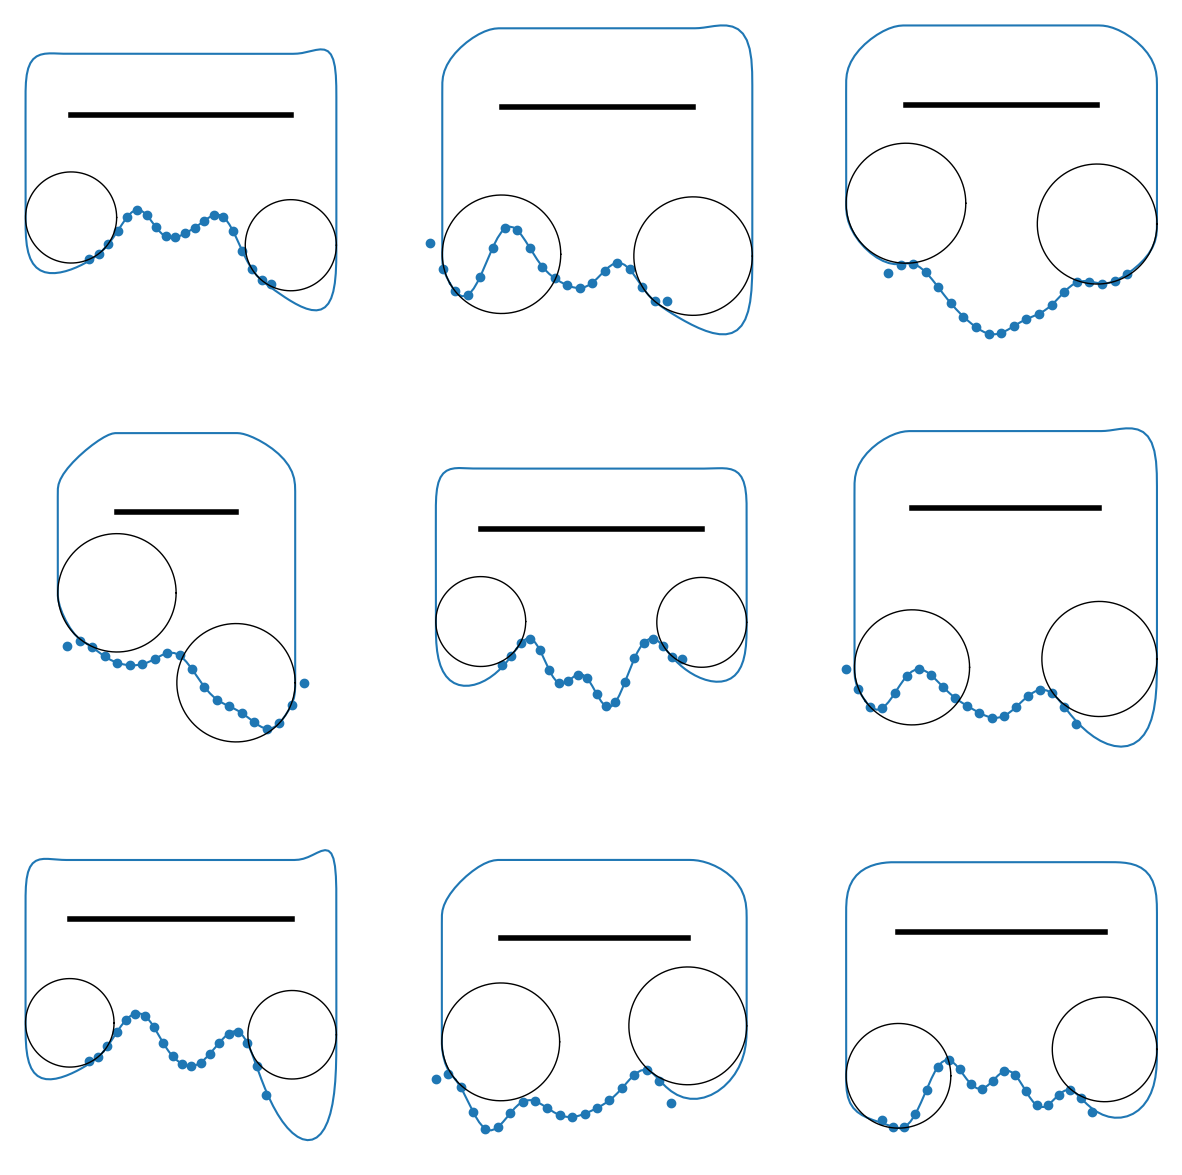

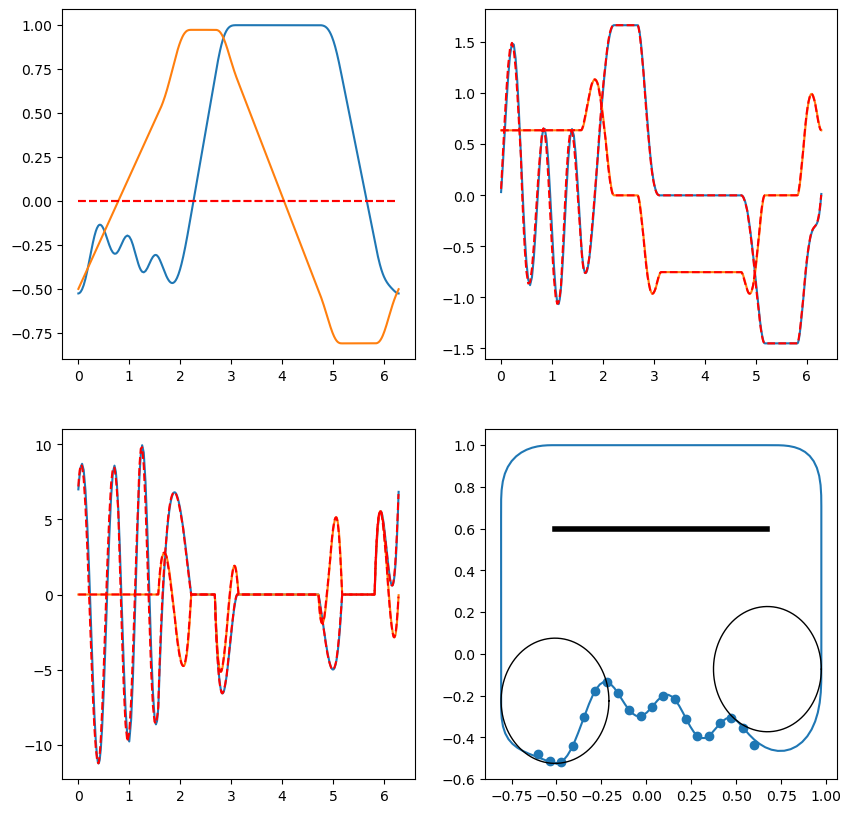

In [2]:
np.random.seed(0)
n = 3
plt.figure(figsize=(15,15))
riesz = []
zvec = []
for i in range(n * n):
    
    plt.subplot(n,n,i+1)
    mg = GPDomain("exp", 
                  shape=.05, 
                  num=20, 
                  scale=.05, 
                  bound=.3, 
                  width=1, 
                  height=1, 
                  corner_w = 0.3,
                  line_pos=0.6, 
                  n_refine=2, 
                  n_corner_refine=0)   
    
    mg.plot(ax=plt.gca())
    remove_axes(plt.gca())
    plt.axis("equal")


    
plt.figure(figsize=(10,10))
plt.subplot(2,2,4)
mg.plot(ax=plt.gca())
t,w = mg.grid.get_grid_and_weights()
ddz = np.zeros_like(t[:-1])
for der in range(3):
    dz = mg.eval_param(derivative=der)
    plt.subplot(2,2,der+1)
    plt.plot(t,np.imag(dz))
    plt.plot(t,np.real(dz))
    plt.plot(t[:-1],np.imag(ddz), 'r--')
    plt.plot(t[:-1],np.real(ddz), 'r--')
    ddz = (dz[1:]-dz[:-1])/(t[1:]-t[:-1])
    

Convergence state 0
Convergence state 0
Convergence state 0
Convergence state 0


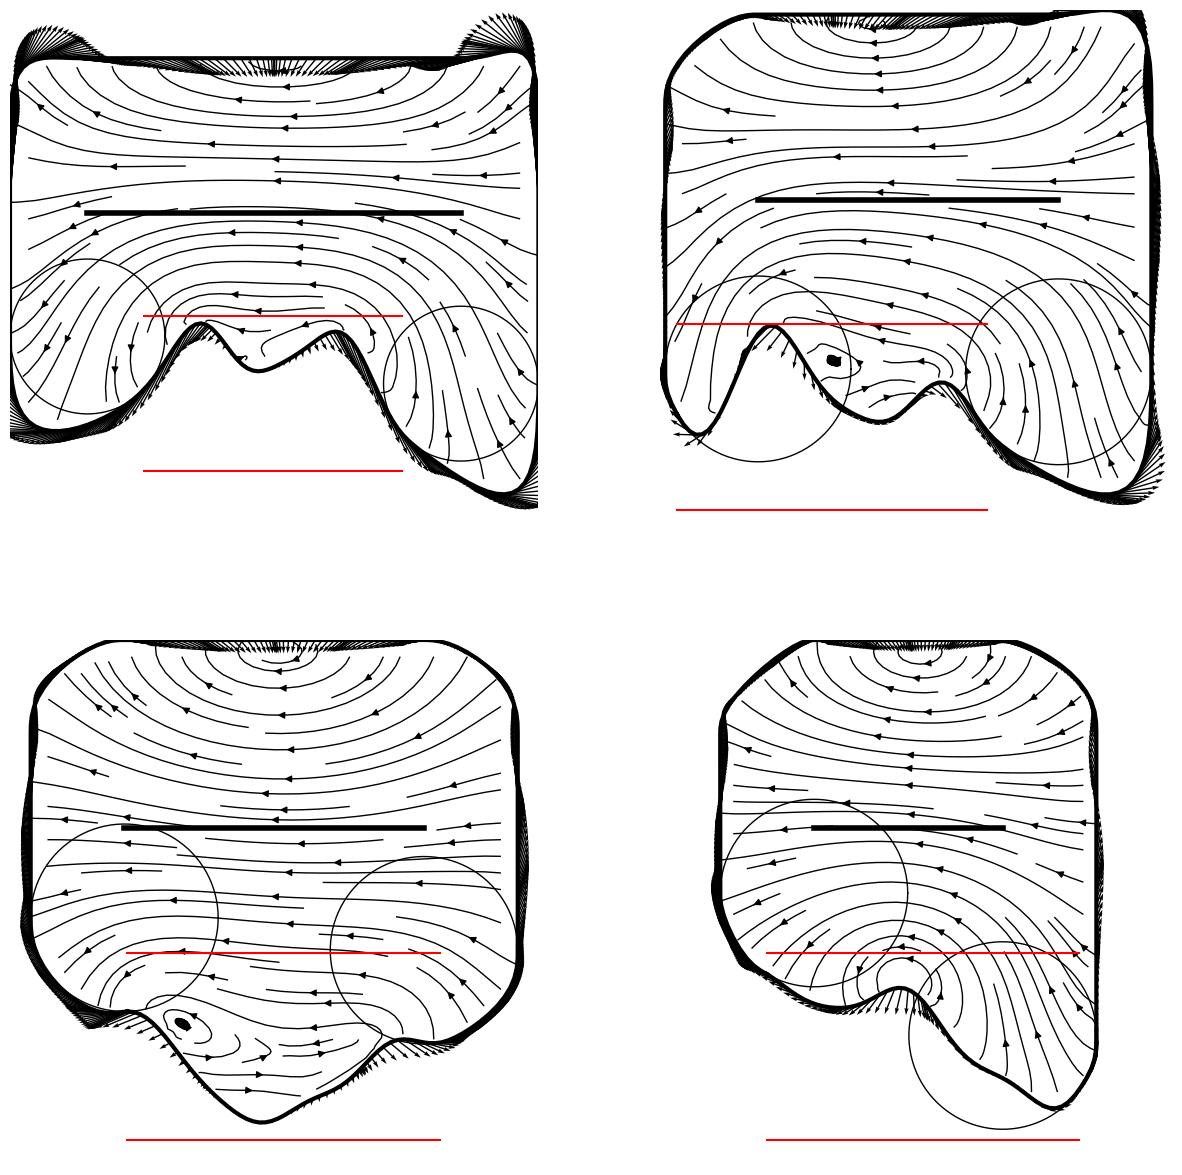

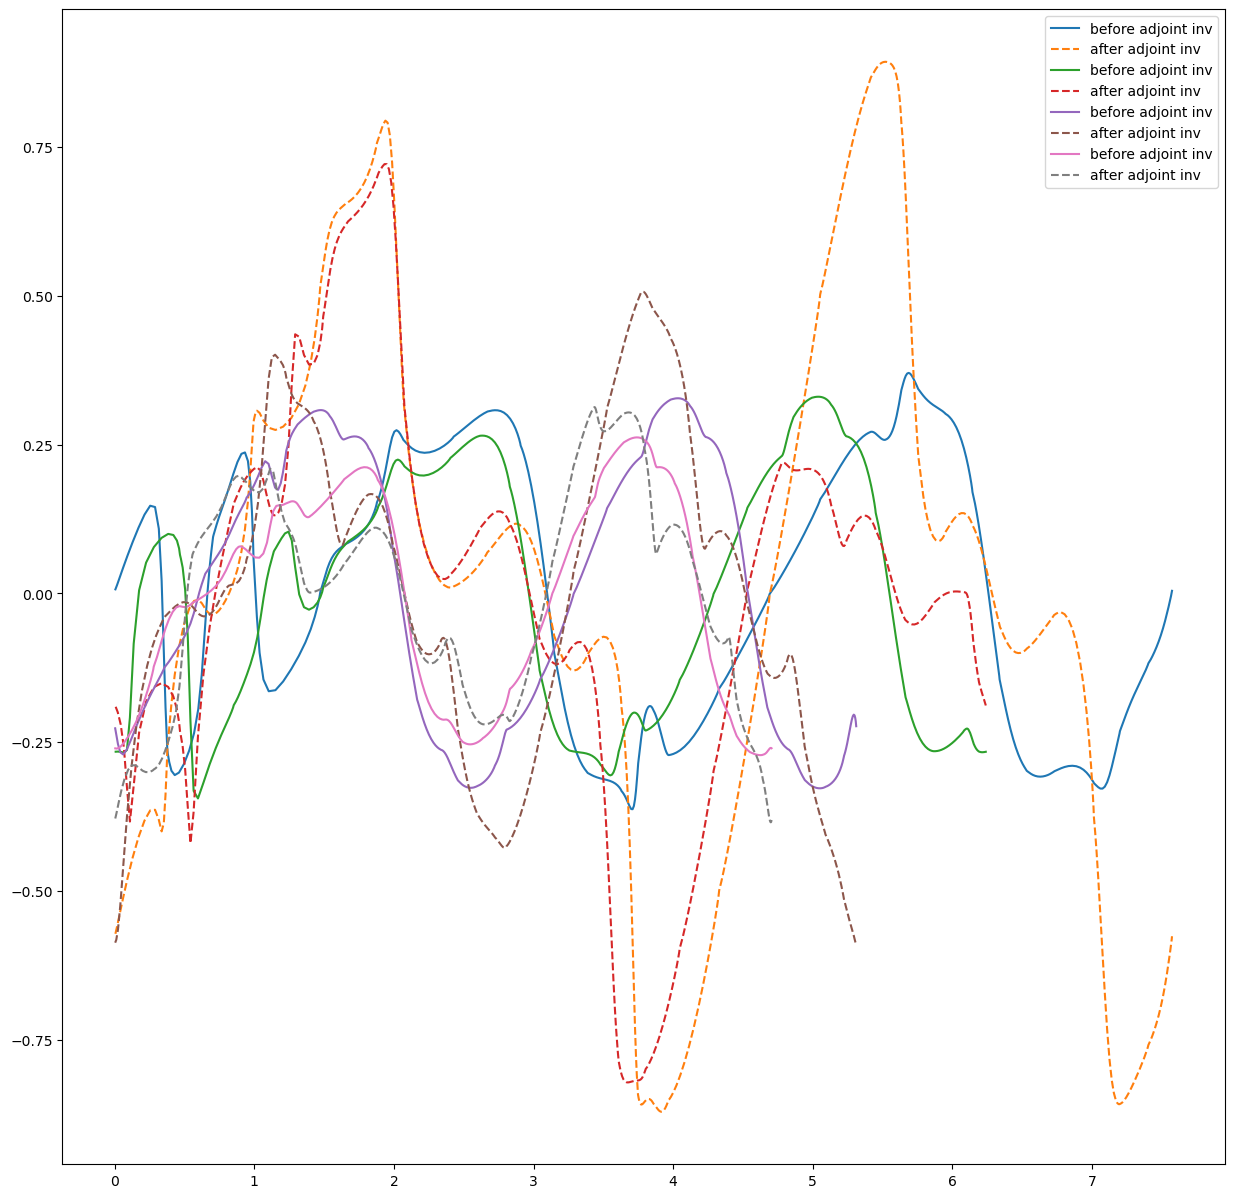

In [7]:
np.random.seed(0)
n = 2
plt.figure(figsize=(15,15))
plt.figure(figsize=(15,15))
riesz = []
zvec = []
for i in range(n * n):
    
    mg = GPDomain("exp", 
                  shape=.05, 
                  num=20, 
                  scale=.05, 
                  bound=.3, 
                  width=1, 
                  height=1, 
                  corner_w = 0.3,
                  line_pos=0.4, 
                  n_refine=2, 
                  n_corner_refine=0)    
    
    r1, func = mg.precompute_line_avg(derivative=0, tol=1e-10, maxiter=40, verbose=True)
    r2, _    = mg.precompute_line_avg(derivative=1, tol=1e-10, maxiter=40)
    r3, _    = mg.line_eval_adjoint(derivative=0, tol=1e-10, maxiter=40)
    mg.data["riesz_vec"]     = r1
    mg.data["riesz_vec_der"] = r2
    z = mg.eval_param()
    dz = mg.eval_param(derivative=1)
    a = mg.curve_length()
    
    # To test, plot field corresponding to riesz vector
    v = mg.zero_flow(r1*1j)
    v /= np.linalg.norm(v)
    condition = lambda t: v
    problem = StokesDirichletProblem(mg, condition)
    problem.solve(tol=1e-9, maxiter=40)
    
    ### PLOT ###
    print(f"{i+1}/{n*n} done", end="\r")
   
    
    vel = lambda z: np.abs(problem.evaluate(z))
    #problem.geometry.plot_field(ax=plt.gca(), func=vel, apply_mask=True, cmap='inferno', vmax=np.max(np.abs(v)))
    #problem.geometry.plot_stream(ax=plt.gca(), func=problem.evaluate, apply_mask=True, color='white')
    #plt.quiver(np.real(z), np.imag(z), np.real(r1), np.imag(r1), color="red", scale=5)
    #mg.plot(ax=plt.gca(), show_samples=False, color="white", linewidth=3)  
    
    
    plt.figure(1)
    plt.subplot(n,n,i+1) 
    problem.geometry.plot_stream(ax=plt.gca(), func=lambda z: problem.evaluate(z), apply_mask=True, color='black', linewidth=1)
    plt.quiver(np.real(z), np.imag(z), np.real(r1), np.imag(r1), color="black", scale=8)
    mg.plot(ax=plt.gca(), show_samples=False, color="black", linewidth=3)  
    
    plt.plot([-0.5,0.5], [0,0], "red")
    plt.plot([-0.5,0.5], [-0.6,-0.6], "red")
    
    #plt.xlim([-1,1])
    #plt.xlim([-1,1])
    plt.axis("equal")
    remove_axes(plt.gca())
    
    plt.figure(2)
    #plt.subplot(n,n,i+1) 
    plt.plot(a, np.real(r3), label="before adjoint inv")
    plt.plot(a, np.real(r1), '--', label="after adjoint inv")
    plt.legend()
    
    riesz.append(r1)
    zvec.append(z)
    
#plt.figure()
#for r in riesz:
#    plt.plot(np.imag(r))

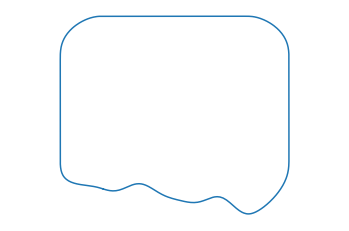

In [4]:
z_mean = np.zeros_like(zvec[0])
for z in zvec:
    z_mean += z / n**2

plt.plot(np.real(z_mean), np.imag(z_mean))
plt.axis("equal")
remove_axes(plt.gca())

## Generating a data set

In [5]:
np.random.seed(0)
N = 20
plt.figure(figsize=(15,15))
riesz = []
zvec = []
for i in range(N):
    print(f"{i+1}/{N} done", end="\n")
    mg = GPDomain("exp", 
                  shape=.05, 
                  num=20, 
                  scale=.05, 
                  bound=.3, 
                  width=1, 
                  height=1, 
                  corner_w = 0.3,
                  line_pos=np.random.rand()*0.4 + 0.2, 
                  n_refine=1, 
                  n_corner_refine=0)    
    
    r1, func = mg.precompute_line_avg(derivative=0, tol=1e-12, maxiter=200, verbose=True)
    r2, _    = mg.precompute_line_avg(derivative=1, tol=1e-12, maxiter=200, verbose=True)
    r3, _    = mg.line_eval_adjoint(derivative=0, tol=1e-12, maxiter=200, verbose=True)
    r4, _    = mg.line_eval_adjoint(derivative=1, tol=1e-12, maxiter=200, verbose=True)
    
    
    c = 1j + 1
    vec = np.conjugate(mg.eval_param()) - c
    a = mg.line_pos * 1j - 0.45 * mg.width - c
    b = mg.line_pos * 1j + 0.45 * mg.width - c
    print(f"numerical: {func(vec)}, true: {np.real(b**2 - a**2)/2}")
    
    mg.data["riesz_vec"]     = r1
    mg.data["riesz_vec_der"] = r2
    mg.data["line_eval_adjoint"] = r3
    mg.data["line_eval_der_adjoint"] = r4
    
    #mg.plot(ax=plt.gca(), shownormals=True, showpts=True, npts=500)
    #mg.plot(ax=plt.gca(), npts=300)
    
    mg.save(f"/home/emastr/phd/data/rounded_micro_domains_w_riesz_vectors_2/domain_{i}.GPDomain")
    
    #data = torch.load(f"/home/emastr/phd/data/rounded_micro_domains_w_riesz_vectors/domain_{i}.GPDomain")
    #data.pop("riesz_vec")
    #data.pop("riesz_vec_der")
    #data.pop("line_eval_adjoint")
    #data.pop("line_eval_der_adjoint")
    #mg = GPDomain.load(f"/home/emastr/phd/data/rounded_micro_domains_w_riesz_vectors/domain_{i}.GPDomain")
    #mg.plot(ax=plt.gca(), npts=300, linestyle='--')
    #plt.axis("equal")
    #remove_axes(plt.gca())
    #plt.xlim([-1,1])
    #plt.ylim([-0.5,1.2])
    #remove_axes(plt.gca())

1/20 done
Converged in 0 iterations
Converged in 0 iterations
numerical: -0.9000313333173318, true: -0.9
2/20 done
Converged in 0 iterations
Converged in 0 iterations
numerical: -0.8999994782681047, true: -0.9
3/20 done
Converged in 0 iterations
Converged in 0 iterations
numerical: -0.8999998402815546, true: -0.8999999999999999
4/20 done
Converged in 0 iterations
Converged in 0 iterations
numerical: -0.8999999442103604, true: -0.9
5/20 done
Converged in 0 iterations
Converged in 0 iterations
numerical: -0.8999999410312983, true: -0.9
6/20 done
Converged in 0 iterations
Converged in 0 iterations
numerical: -0.8999999347591428, true: -0.9
7/20 done
Converged in 0 iterations
Converged in 0 iterations
numerical: -0.8999985554029096, true: -0.9
8/20 done
Converged in 0 iterations
Converged in 0 iterations
numerical: -0.9000001329230867, true: -0.9
9/20 done
Converged in 0 iterations
Converged in 0 iterations
numerical: -0.8999518115787597, true: -0.9
10/20 done
Converged in 0 iterations
Con

<Figure size 1080x1080 with 0 Axes>

# Convert to PyTorch Tensor

In [6]:
# 200 000 data points, we run through
import os

os.makedirs("/home/emastr/phd/data/rounded_micro_domains_adjoint", exist_ok=True)
N = 2000

for j in range(100):
    start = j * N
    M = len(r1)

    in_ch = ["zr", "zi", "dzr", "dzi", "ddzr", "ddzi", "line_eval_r", "line_eval_i", "w", "t"]
    out_ch = ["riesz_r", "riesz_i"]
    for i in range(N):

        in_data = torch.zeros(N, len(in_ch), M)
        out_data = torch.zeros(N, len(out_ch), M)

        print(f"{start + i + 1}/{200000} done", end="\r")
        data = torch.load(f"/home/emastr/phd/data/rounded_micro_domains_w_riesz_vectors_2/domain_{start + i}.GPDomain")
        riesz = data.pop("riesz_vec")
        line_eval = data.pop("line_eval_adjoint")
        data.pop("riesz_vec_der")
        data.pop("line_eval_der_adjoint")

        geom = GPDomain.load(data)
        t, w = geom.grid.get_grid_and_weights()
        z = geom.eval_param(derivative=0)
        dz = geom.eval_param(derivative=1)
        ddz = geom.eval_param(derivative=2)

        n = dz/np.abs(dz)
        r = np.imag(dz * np.conjugate(ddz))/np.abs(dz)**3 * n

        # Set in data
        in_data[i, 0, :] = torch.from_numpy(np.real(z))
        in_data[i, 1, :] = torch.from_numpy(np.imag(z))
        in_data[i, 2, :] = torch.from_numpy(np.real(dz))
        in_data[i, 3, :] = torch.from_numpy(np.imag(dz))
        in_data[i, 4, :] = torch.from_numpy(np.real(ddz))
        in_data[i, 5, :] = torch.from_numpy(np.imag(ddz))
        in_data[i, 6, :] = torch.from_numpy(np.real(line_eval))
        in_data[i, 7, :] = torch.from_numpy(np.imag(line_eval))
        in_data[i, 8, :] = torch.from_numpy(w)
        in_data[i, 9, :] = torch.from_numpy(t)

        # set out data
        out_data[i, 0, :] = torch.from_numpy(np.real(riesz))
        out_data[i, 1, :] = torch.from_numpy(np.imag(riesz))


        # Save data to file
        data = {"X": in_data, "Y": out_data, "info": {"in_ch": in_ch, "out_ch": out_ch}}
        torch.save(data, f"/home/emastr/phd/data/rounded_micro_domains_adjoint/data_{j}.torch")


In [12]:
mg.grid.integrate(lambda t: np.ones_like(t)) / (2*np.pi)

t,_ = mg.grid.get_grid_and_weights()
dz = mg.eval_param(derivative=1)

print(mg.grid.integrate(lambda t: np.abs(mg.eval_param(derivative=1))))
print(np.sum(np.abs(dz)[:-1] * (t[1:]-t[:-1])))

5.820757465097854
5.804797919424254


## Independence to parameterisation
We verify that the riesz representor is invariant to reparameterisation.

Resample # 0


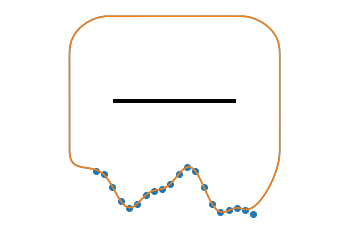

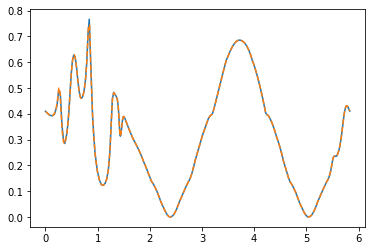

In [18]:
geom = GPDomain("exp", 
                  shape=.05, 
                  num=20, 
                  scale=.05, 
                  bound=.3, 
                  width=1, 
                  height=1, 
                  corner_w = 0.3,
                  line_pos=np.random.rand()*0.4 + 0.2, 
                  n_refine=2, 
                  n_corner_refine=0)    

z, dz, ddz = geom.param

t = lambda s: s  ** 2
dt = lambda s: 2 * s
ddt = lambda s: 2 * np.ones_like(s)

t_inv = lambda t: np.sqrt(t)
dom_s = t_inv(geom.grid.segments)

z_s = lambda s: z(t(s))
dz_s = lambda s: dt(s) * dz(t(s))
ddz_s = lambda s: ddt(s) * dz(t(s)) + (dt(s)**2) * ddz(t(s))

param = [z_s, dz_s, ddz_s]
grid = GaussLegGrid(segments=dom_s, corners=np.ones_like(dom_s).astype(int))
geom_s = Geometry(param, grid)

geom_s.plot(ax=plt.gca())
geom.plot(ax=plt.gca())

r1,_ = geom_s.line_eval_adjoint(-0.45*geom.width + 1j*geom.line_pos, 0.45*geom.width+1j*geom.line_pos, derivative=0)
a1 = geom_s.curve_length()

r2,_ = geom.line_eval_adjoint(derivative=0)
a2 = geom.curve_length()

plt.axis("equal")
remove_axes(plt.gca())

plt.figure()
plt.plot(a1, np.real(r1))
plt.plot(a2, np.real(r2), '--')